# Exploring the Data


# Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import pickle

from sklearn.impute import SimpleImputer

sys.path.append(os.path.abspath(".."))

import python_code.Scripts3 as sc
import python_code.Reference as ref

print("Everything imported successfully")

Everything imported successfully


In [2]:
print(os.getcwd())

E:\BootcampGIS\Lesson 3 _ Analyze pandemic food insecurity using Data Science and GIS\data\qgis-data-project\notebooks


## First glance...
These datasets contains information about each household that received SNAP benefits in 2007 and 2017. Each household is representated by a record and goes on to record information about each member of the household.

For our purposes, we will break this down into two states of interest: New Mexico and Nebraska. This is due to a previous geographical analysis of emerging hot and cold spots targeting San Juan County, New Mexico as a new hot spot and Cherry County, Nebraska as a new cold spot.

# Data

## 2007 Data

In [3]:
snap07 = pd.read_spss('../data/qc_pub_fy2007.sav')

In [4]:
snap07.head(5)

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,NDISCA7,NDISCA8,NDISCA9,NDISCA10,NDISCA11,NDISCA12,NDISCA13,NDISCA14,NDISCA15,NDISCA16
0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
snap07.shape

(47469, 769)

In [6]:
snap07.info()

<class 'pandas.DataFrame'>
RangeIndex: 47469 entries, 0 to 47468
Columns: 769 entries, FSAFIL1 to NDISCA16
dtypes: float64(769)
memory usage: 278.5 MB


In [7]:
snap07.isnull().sum()

FSAFIL1         0
FSAFIL2     20739
FSAFIL3     29470
FSAFIL4     36884
FSAFIL5     42301
            ...  
NDISCA12    47455
NDISCA13    47463
NDISCA14    47466
NDISCA15    47469
NDISCA16    47469
Length: 769, dtype: int64

## 2017 Data

In [8]:
snap17 = pd.read_csv('../data/qc_pub_fy2017.csv')

In [9]:
snap17.head(5)

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,WORK12,WORK13,WORK14,WORK15,WORK16,FSNONCIT,FSDIS,FSELDER,FSKID,STATENAME
0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Connecticut
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,Connecticut
2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,0,0,Connecticut
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,1,0,0,Connecticut
4,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,1,0,Connecticut


In [10]:
snap17.shape

(45530, 814)

In [11]:
snap17.info()

<class 'pandas.DataFrame'>
RangeIndex: 45530 entries, 0 to 45529
Columns: 814 entries, FSAFIL1 to STATENAME
dtypes: float64(368), int64(445), str(1)
memory usage: 282.8 MB


In [12]:
snap17.isnull().sum()

FSAFIL1          0
FSAFIL2      22368
FSAFIL3      30458
FSAFIL4      36350
FSAFIL5      40801
             ...  
FSNONCIT         0
FSDIS            0
FSELDER          0
FSKID            0
STATENAME        0
Length: 814, dtype: int64

## Target Variable
CAT_ELIG

In [13]:
#2007: 1 = Eligible, 2= Not eligible
snap07['CAT_ELIG'].value_counts()

CAT_ELIG
2.0    25134
1.0    22335
Name: count, dtype: int64

In [14]:
#2017: 0 = Not eligible, 1 = Reported eligible, 2 = Recorded eligible
snap17['CAT_ELIG'].value_counts()

CAT_ELIG
1    36223
0     7012
2     2295
Name: count, dtype: int64

**Observations:** The variable has different outputs. I am going to reclassify so both datasets match.

- 0 = Not Elgible
- 1 = Elgible

In [15]:
snap07['CAT_ELIG'] = snap07['CAT_ELIG'].replace(2,0)
snap17['CAT_ELIG'] = snap17['CAT_ELIG'].replace(2,1)

In [16]:
snap07['CAT_ELIG'].value_counts()

CAT_ELIG
0.0    25134
1.0    22335
Name: count, dtype: int64

In [17]:
snap17['CAT_ELIG'].value_counts()

CAT_ELIG
1    38518
0     7012
Name: count, dtype: int64

In [18]:
print(f'2017 dataset: {snap17.shape} VS 2007 dataset: {snap07.shape}')

2017 dataset: (45530, 814) VS 2007 dataset: (47469, 769)


**Observations:** Less people nationally applied for SNAP benefits in 2017 as opposed to 2007. This probably had to do with stronger national economic factors such as employment opportunities. Also, 45 columns of features were added to the dataset.

## Reference Tables

In [19]:
print(f'Unit Demo, 2007 is {ref.unit07_demo.shape[0]} and 2017 is {ref.unit17_demo.shape[0]}')
print(f'Unit Assets, 2007 is {ref.unit07_assets.shape[0]} and 2017 is {ref.unit17_assets.shape[0]}')
print(f'Unit ExDed, 2007 is {ref.unit07_exded.shape[0]} and 2017 is {ref.unit17_exded.shape[0]}')
print(f'Unit Inc, 2007 is {ref.unit07_inc.shape[0]} and 2017 is {ref.unit17_inc.shape[0]}')
print(f'Pers Char, 2007 is {ref.per07_char.shape[0]} and 2017 is {ref.per17_char.shape[0]}')
print(f'Pers Inc, 2007 is {ref.per07_inc.shape[0]} and 2017 is {ref.per17_inc.shape[0]}')

Unit Demo, 2007 is 22 and 2017 is 30
Unit Assets, 2007 is 7 and 2017 is 11
Unit ExDed, 2007 is 27 and 2017 is 27
Unit Inc, 2007 is 26 and 2017 is 27
Pers Char, 2007 is 14 and 2017 is 17
Pers Inc, 2007 is 20 and 2017 is 21


**Observations:** From 2007 to 2017, every category obtained more columns except for Expenses and Deductables.

# Extracting the State Data
31 - NE - Nebraska & 35 - NM - New Mexico

## New Mexico 

In [20]:
#save New Mexico records
#2007
nm07 = snap07.loc[snap07['STATE'] == 35].astype('float64')
nm07_target = nm07['CAT_ELIG']
nm07.to_csv('../data/nm07.csv',index=None)

In [21]:
#2017
nm17 = snap17.loc[snap17['STATE'] == 35]
nm17_target = nm17['CAT_ELIG']
nm17 = nm17.drop(columns = ['STATENAME'])
nm17 = nm17.astype('float64')
nm17.to_csv('../data/nm17.csv',index=None)

In [22]:
#setting New Mexico dataframe
df_nm07 = pd.read_csv('../data/nm07.csv')
df_nm07

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,NDISCA7,NDISCA8,NDISCA9,NDISCA10,NDISCA11,NDISCA12,NDISCA13,NDISCA14,NDISCA15,NDISCA16
0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1251,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1252,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1253,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
df_nm17 = pd.read_csv('../data/nm17.csv')
df_nm17

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,WORK11,WORK12,WORK13,WORK14,WORK15,WORK16,FSNONCIT,FSDIS,FSELDER,FSKID
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0
2,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
960,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
961,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
962,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0


In [24]:
df_nm07['CAT_ELIG'].value_counts()

CAT_ELIG
0.0    813
1.0    442
Name: count, dtype: int64

In [25]:
df_nm17['CAT_ELIG'].value_counts()

CAT_ELIG
1.0    964
Name: count, dtype: int64

## Nebraska

In [26]:
#save Nebraska records
#2007
ne07 = snap07.loc[snap07['STATE'] == 31].astype('float64')
ne07_target = ne07['CAT_ELIG']
ne07.to_csv('../data/ne07.csv',index=None)

In [27]:
#2017
ne17 = snap17.loc[snap17['STATE'] == 31]
ne17_target = ne17['CAT_ELIG']
ne17 = ne17.drop(columns = ['STATENAME'])
ne17 = ne17.astype('float64')
ne17.to_csv('../data/ne17.csv',index=None)

In [28]:
#setting Nebraska dataframe
df_ne07 = pd.read_csv('../data/ne07.csv')
df_ne07

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,NDISCA7,NDISCA8,NDISCA9,NDISCA10,NDISCA11,NDISCA12,NDISCA13,NDISCA14,NDISCA15,NDISCA16
0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
787,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
788,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
#setting Nebraska dataframe
df_ne17 = pd.read_csv('../data/ne17.csv')
df_ne17

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,WORK11,WORK12,WORK13,WORK14,WORK15,WORK16,FSNONCIT,FSDIS,FSELDER,FSKID
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0
4,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
890,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
891,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0
892,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0


In [30]:
df_ne07['CAT_ELIG'].value_counts()

CAT_ELIG
0.0    505
1.0    286
Name: count, dtype: int64

In [31]:
df_ne17['CAT_ELIG'].value_counts()

CAT_ELIG
1.0    894
Name: count, dtype: int64

# Snapshot of data

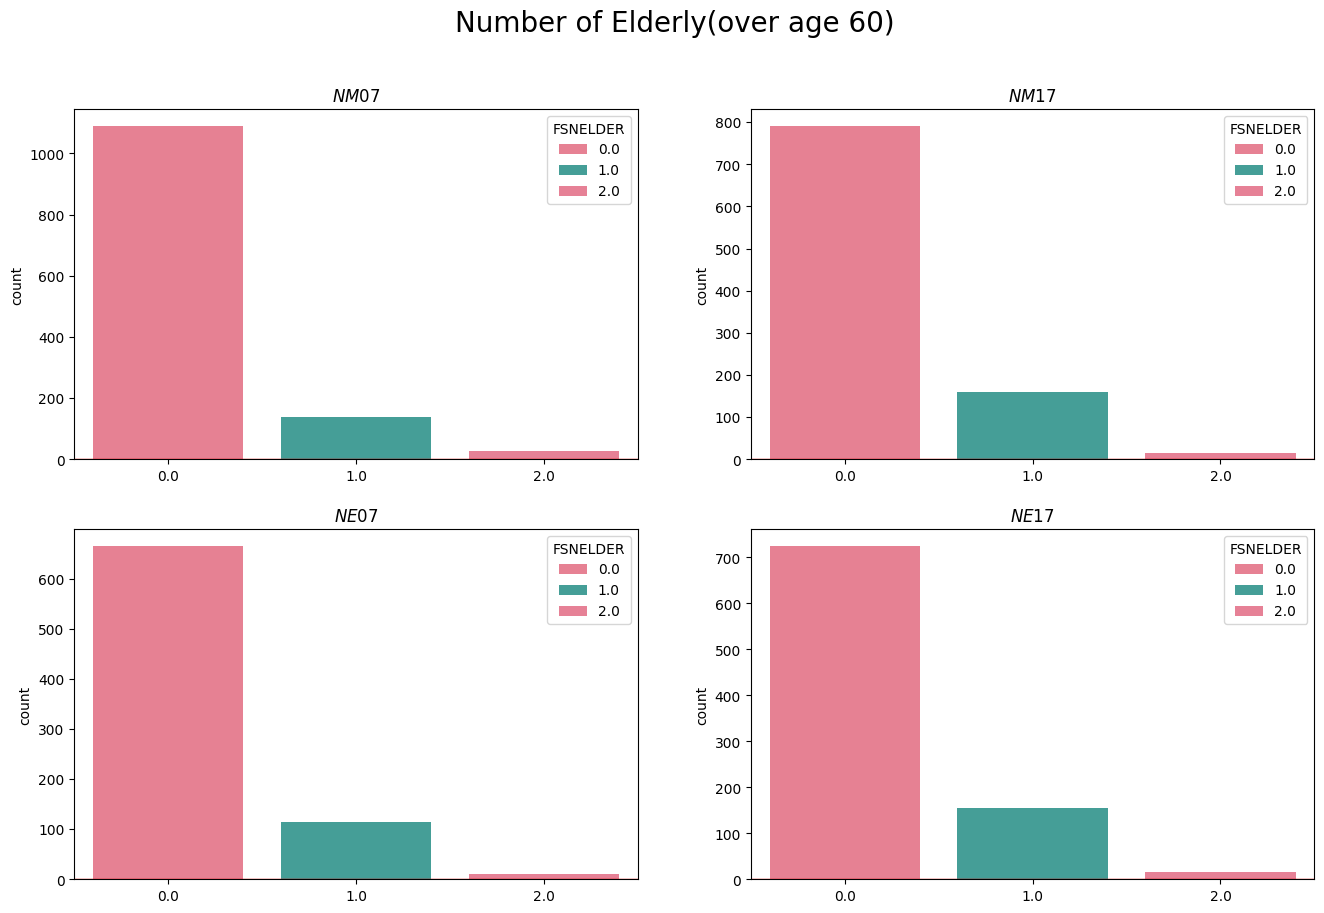

In [32]:
sc.plot_simple_features('FSNELDER','elderly',"Number of Elderly(over age 60)")

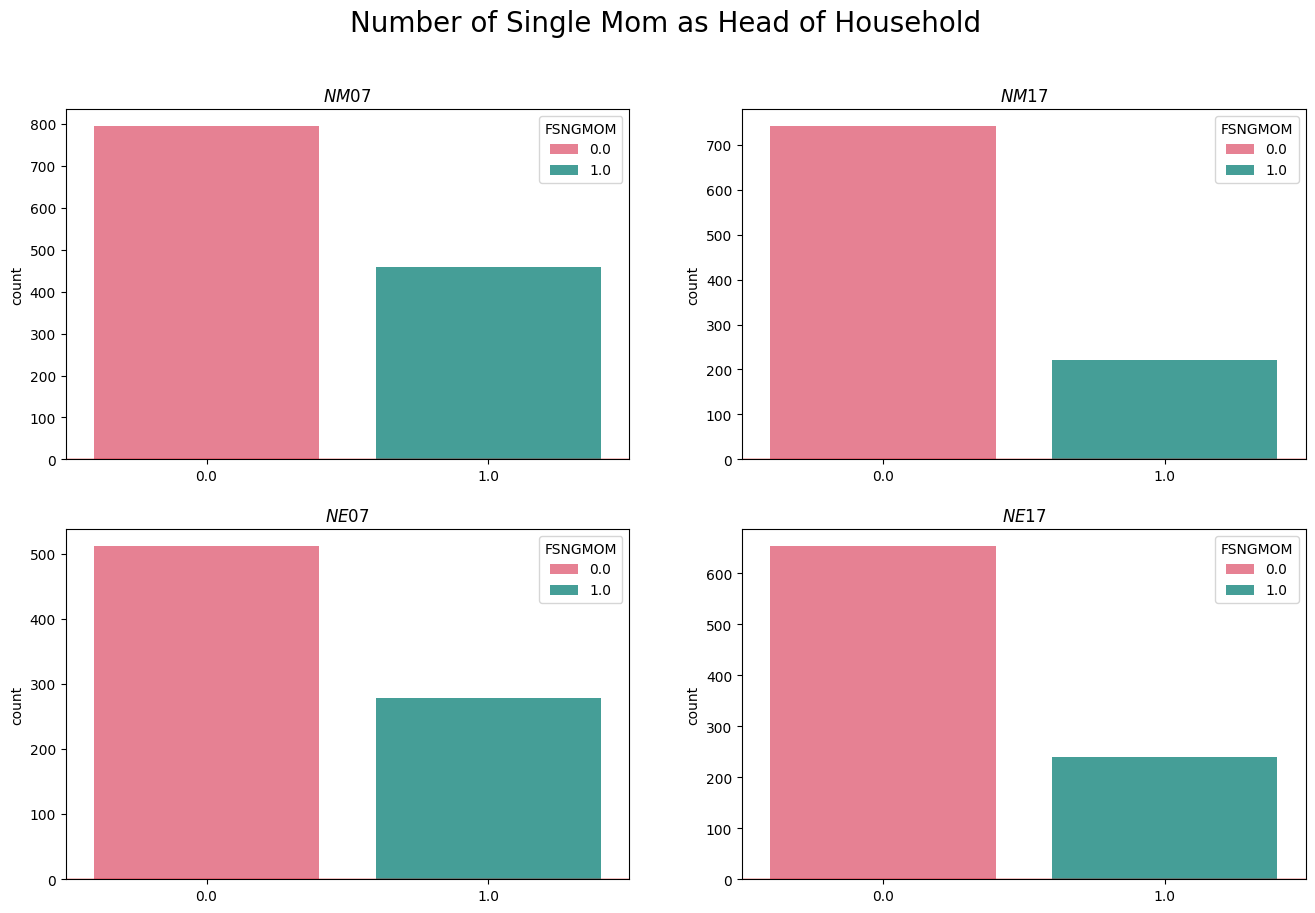

In [33]:
# single-female head of household - FSNGMOM
sc.plot_simple_features('FSNGMOM','single_mom',"Number of Single Mom as Head of Household")

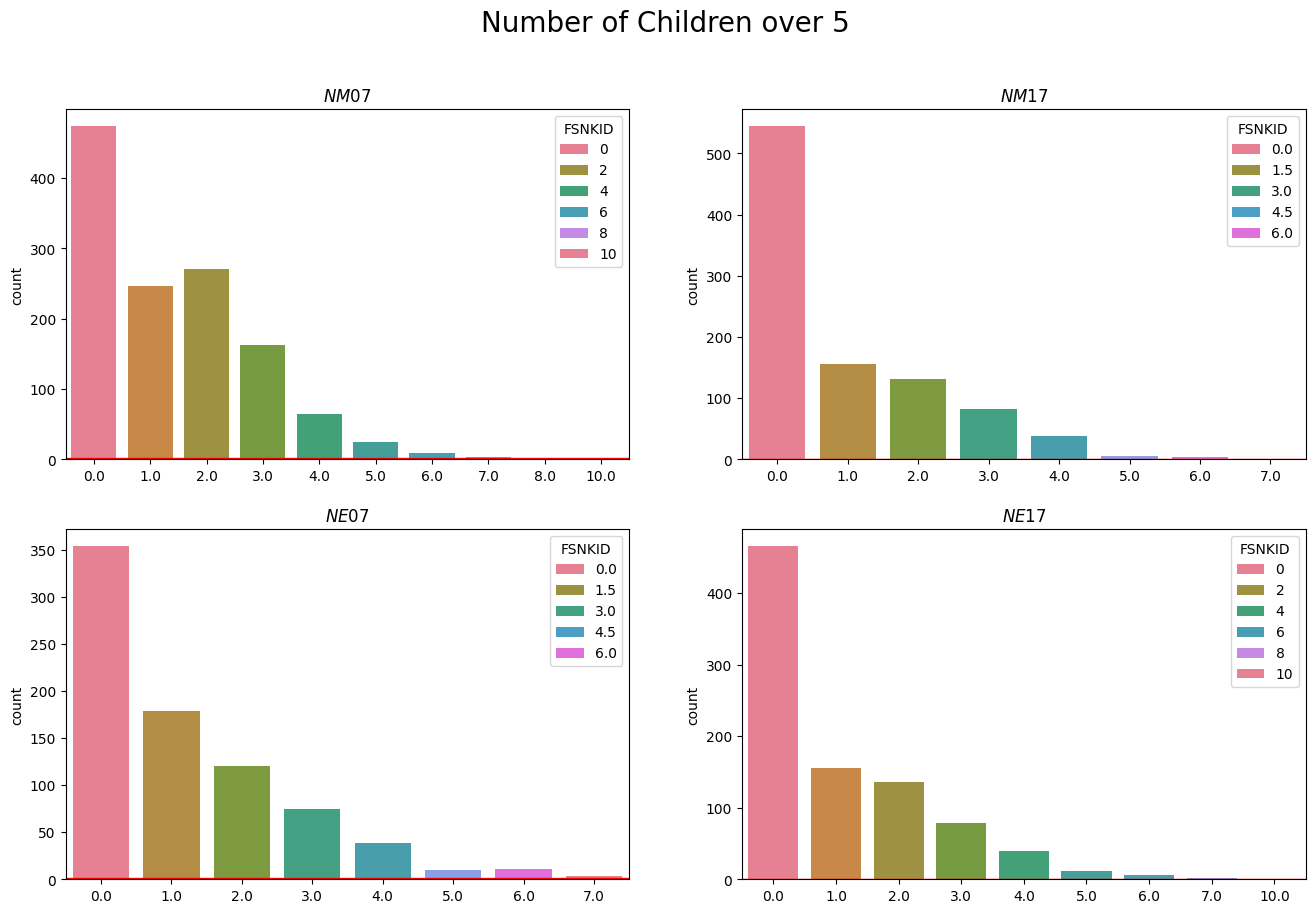

In [34]:
# number of children - FSNKID
sc.plot_simple_features('FSNKID','no_children',"Number of Children over 5")

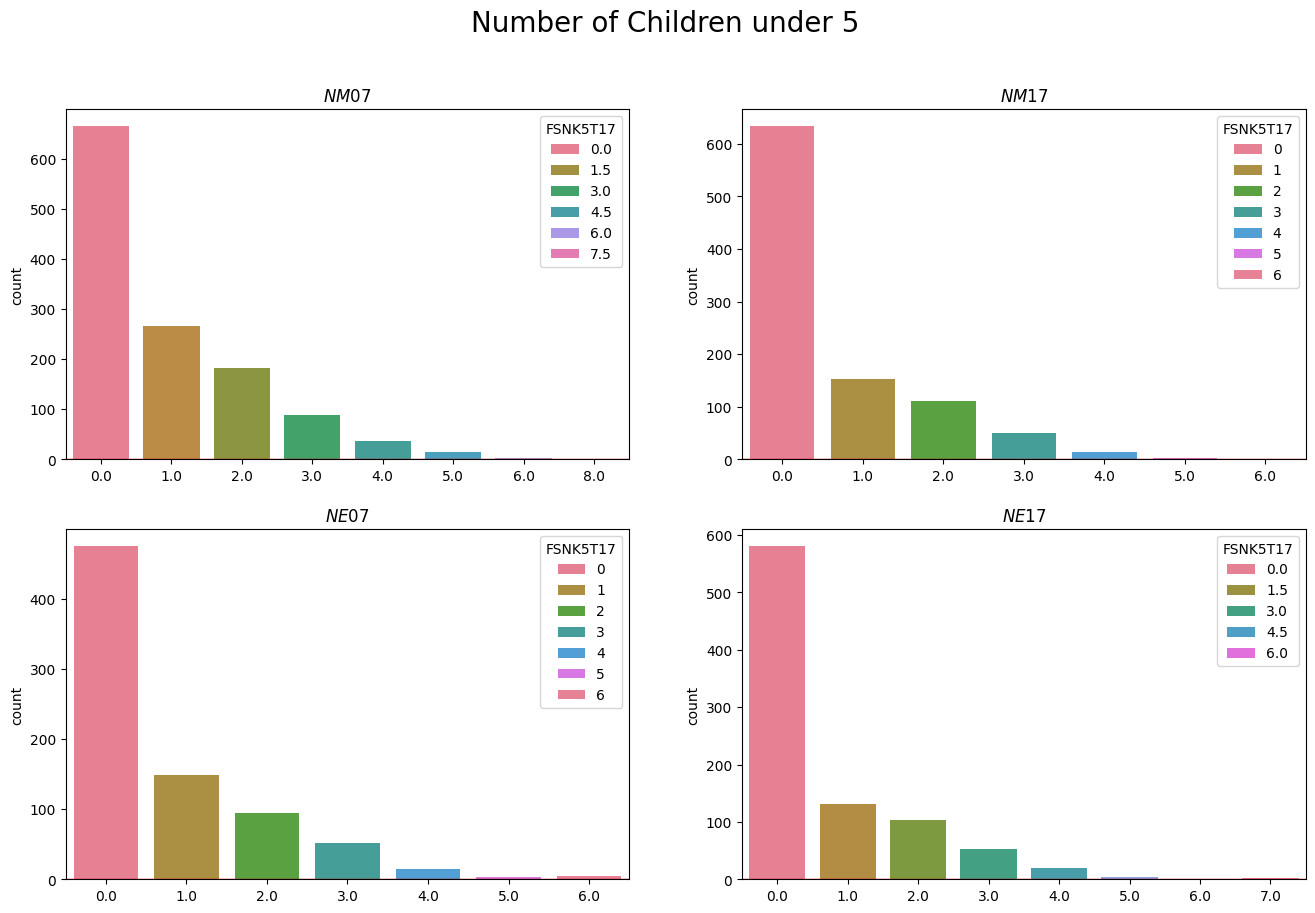

In [35]:
# number of children under 5 = FSNK5T17
sc.plot_simple_features('FSNK5T17','no_toddler',"Number of Children under 5")

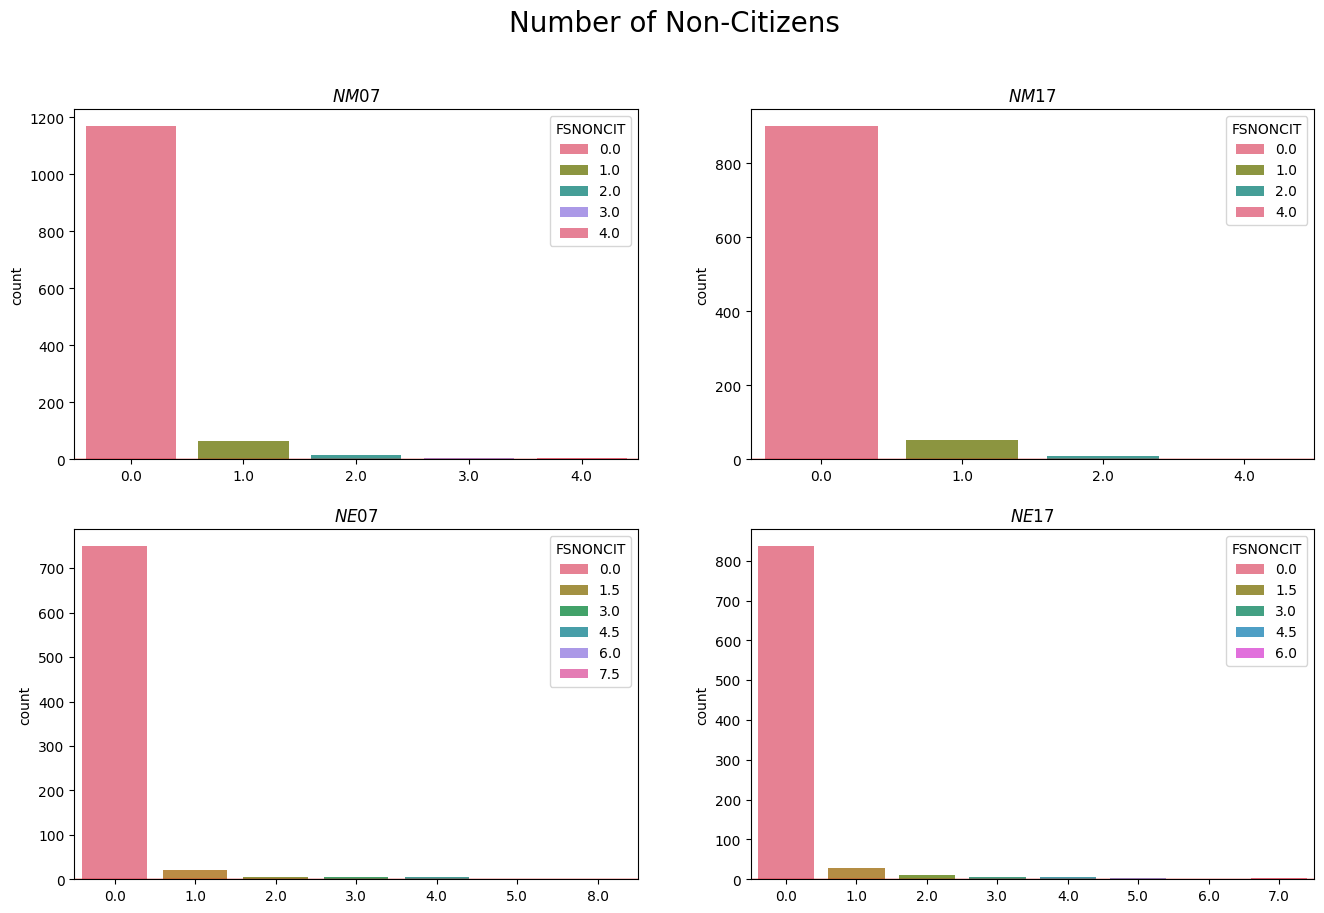

In [36]:
# number of noncitizens in unit = FSNONCIT
sc.plot_simple_features('FSNONCIT','non_citiz',"Number of Non-Citizens")

## Null Values
This section is the initial reduction of columns by different treatments of null values

### Full Missing Values
There are many columns that have no data so they will be removed

###New Mexico

2007

In [37]:
with pd.option_context('display.max_rows',None):
    print(df_nm07.isnull().sum().sort_values(ascending=False)[:96])

RACETH15    1255
ELEMENT8    1255
YRSED13     1255
YRSED14     1255
ELEMENT7    1255
ELEMENT6    1255
NDISCA14    1255
NDISCA13    1255
YRSED15     1255
YRSED16     1255
EMPSTB15    1255
OCCDATE6    1255
FSAFIL13    1255
FSAFIL14    1255
FSAFIL15    1255
FSAFIL16    1255
VERIF9      1255
VERIF7      1255
NDISCA16    1255
DIS16       1255
DIS15       1255
DIS14       1255
DIS13       1255
VERIF6      1255
VERIF8      1255
DISCOV9     1255
EMPRG13     1255
EMPRG14     1255
REL13       1255
REL14       1255
REL15       1255
REL16       1255
EMPRG15     1255
EMPRG16     1255
FSUN16      1255
FSUN15      1255
FSUN14      1255
FSUN13      1255
EMPSTB16    1255
NDISCA15    1255
DISCOV8     1255
DISCOV7     1255
DISCOV6     1255
AGENCY9     1255
AGE13       1255
AGE14       1255
AGE15       1255
AGE16       1255
EMPSTB13    1255
AGENCY8     1255
DPCOST16    1255
DPCOST15    1255
DPCOST14    1255
DPCOST13    1255
AGENCY7     1255
AGENCY6     1255
CTZN15      1255
EMPSTA13    1255
EMPSTA14    12

In [38]:
#Remove those columns
first_cut = df_nm07.isnull().sum().sort_values(ascending=False)[:96]
first_cut_df = pd.DataFrame([first_cut])
first_cut_df.T
fc_list = list(first_cut_df.columns)

#remove them
nm07 = df_nm07.drop(fc_list,axis=1)
nm07

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,NDISCA3,NDISCA4,NDISCA5,NDISCA6,NDISCA7,NDISCA8,NDISCA9,NDISCA10,NDISCA11,NDISCA12
0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1251,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1252,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1253,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
#Nebraska

In [40]:
with pd.option_context('display.max_rows',None):
    print(df_nm17.isnull().sum().sort_values(ascending=False)[:165])

AGE13       964
WORK11      964
WORK12      964
NATURE5     964
NATURE6     964
NATURE7     964
NATURE8     964
NATURE9     964
FSAFIL10    964
FSAFIL11    964
FSAFIL12    964
FSAFIL13    964
NDISCA13    964
EMPSTB11    964
FSAFIL15    964
FSAFIL16    964
EMPSTB12    964
WORK13      964
WORK14      964
WORK15      964
AGENCY4     964
WORK16      964
AGENCY6     964
AGENCY7     964
AGENCY8     964
REL10       964
REL11       964
REL12       964
AGENCY9     964
REL14       964
REL15       964
REL16       964
EMPSTB13    964
DISCOV4     964
DISCOV5     964
DISCOV6     964
DISCOV7     964
DISCOV8     964
DISCOV9     964
VERIF4      964
VERIF5      964
AGE10       964
AGE11       964
AGE12       964
E_FINDG5    964
AGE14       964
AGE15       964
AGE16       964
EMPSTB14    964
VERIF6      964
VERIF7      964
VERIF8      964
VERIF9      964
OCCDATE4    964
OCCDATE5    964
OCCDATE6    964
OCCDATE7    964
SEX10       964
SEX11       964
SEX12       964
SEX13       964
SEX14       964
SEX15   

In [41]:
#Remove those columns
first_cut = df_nm17.isnull().sum().sort_values(ascending=False)[:165]
first_cut_df = pd.DataFrame([first_cut])
first_cut_df.T
fc_list = list(first_cut_df.columns)

#remove them
nm17 = df_nm17.drop(fc_list,axis=1)
nm17

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,REL1,...,WORK4,WORK5,WORK6,WORK7,WORK8,WORK9,FSNONCIT,FSDIS,FSELDER,FSKID
0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,1.0
2,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
960,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
961,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0
962,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0


In [42]:
#Nebraska

2007

In [43]:
with pd.option_context('display.max_rows',None):
    print(df_ne07.isnull().sum().sort_values(ascending=False)[:144])

EMPSTB14    791
ELEMENT8    791
AGENCY8     791
AGENCY7     791
NDISCA14    791
NDISCA13    791
NDISCA12    791
NDISCA11    791
AGENCY6     791
FSAFIL10    791
FSAFIL11    791
FSAFIL12    791
FSAFIL13    791
FSAFIL14    791
FSAFIL15    791
FSAFIL16    791
NDISCA10    791
NDISCA16    791
DIS16       791
DIS15       791
DIS14       791
DIS13       791
DIS12       791
DIS11       791
NATURE9     791
REL10       791
REL11       791
REL12       791
REL13       791
REL14       791
REL15       791
REL16       791
EMPSTB11    791
DIS10       791
FSUN16      791
FSUN15      791
FSUN14      791
FSUN13      791
FSUN12      791
FSUN11      791
NDISCA15    791
AGE10       791
AGE11       791
AGE12       791
AGE13       791
AGE14       791
AGE15       791
AGE16       791
EMPSTB12    791
FSUN10      791
DPCOST16    791
DPCOST15    791
DPCOST14    791
DPCOST13    791
DPCOST12    791
DPCOST11    791
NATURE8     791
SEX10       791
SEX11       791
SEX12       791
SEX13       791
SEX14       791
SEX15   

In [44]:
#Remove those columns
first_cut = df_ne07.isnull().sum().sort_values(ascending=False)[:144]
first_cut_df = pd.DataFrame([first_cut])
first_cut_df.T
fc_list = list(first_cut_df.columns)

#remove them
ne07 = df_ne07.drop(fc_list,axis=1)
ne07

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,REL1,...,FSNDISCA,NDISCA1,NDISCA2,NDISCA3,NDISCA4,NDISCA5,NDISCA6,NDISCA7,NDISCA8,NDISCA9
0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
786,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,2.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
787,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
788,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
789,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,2.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
#Nebraska

In [46]:
with pd.option_context('display.max_rows',None):
    print(df_ne17.isnull().sum().sort_values(ascending=False)[:91])

WORK16      894
NATURE7     894
CTZN14      894
CTZN15      894
CTZN16      894
NATURE8     894
NATURE9     894
AGENCY5     894
AGENCY6     894
AGENCY7     894
AGENCY8     894
AGENCY9     894
DISCOV5     894
DISCOV6     894
FSAFIL15    894
FSAFIL16    894
DISCOV7     894
DISCOV8     894
DISCOV9     894
VERIF5      894
YRSED14     894
YRSED15     894
YRSED16     894
EMPSTB15    894
VERIF6      894
VERIF7      894
VERIF8      894
VERIF9      894
OCCDATE5    894
REL14       894
REL15       894
REL16       894
OCCDATE6    894
OCCDATE7    894
OCCDATE8    894
OCCDATE9    894
TIMEPER5    894
TIMEPER6    894
TIMEPER7    894
EMPRG14     894
EMPRG15     894
NATURE6     894
EMPRG16     894
EMPSTB16    894
TIMEPER8    894
AGE14       894
AGE15       894
AGE16       894
TIMEPER9    894
E_FINDG5    894
E_FINDG6    894
E_FINDG7    894
E_FINDG8    894
E_FINDG9    894
WRKREG14    894
WRKREG15    894
WRKREG16    894
ABWDST14    894
ABWDST15    894
EMPSTA14    894
EMPSTA15    894
SEX14       894
SEX15   

In [47]:
#Remove those columns
first_cut = df_ne17.isnull().sum().sort_values(ascending=False)[:91]
first_cut_df = pd.DataFrame([first_cut])
first_cut_df.T
fc_list = list(first_cut_df.columns)

#remove them
ne17 = df_ne17.drop(fc_list,axis=1)
ne17

,FSAFIL1,FSAFIL2,FSAFIL3,FSAFIL4,FSAFIL5,FSAFIL6,FSAFIL7,FSAFIL8,FSAFIL9,FSAFIL10,...,WORK8,WORK9,WORK10,WORK11,WORK12,WORK13,FSNONCIT,FSDIS,FSELDER,FSKID
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,0.0
4,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
890,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
891,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,1.0
892,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0


### Partial Missing: High Nullity

In [48]:
dict_df = {'nm07':nm07,'nm17':nm17,'ne07':ne07,'ne17':ne17}

In [49]:
for key, value in dict_df.items():
    print(f'50% mark for high nullitary columns:')
    print(f'{key}: {round(value.shape[0]/2)}')

50% mark for high nullitary columns:
nm07: 628
50% mark for high nullitary columns:
nm17: 482
50% mark for high nullitary columns:
ne07: 396
50% mark for high nullitary columns:
ne17: 447


In [50]:
all_df_att = pd.DataFrame(dict_df.keys(), columns = ['name'])
all_df_att['rows'] = [value.shape[0] for key,value in dict_df.items()]
all_df_att['threshold'] = [round(value.shape[0]/2) for key,value in dict_df.items()]
all_df_att['start_col'] = [value.shape[1] for key,value in dict_df.items()]
all_df_att

,name,rows,threshold,start_col
0,nm07,1255,628,673
1,nm17,964,482,648
2,ne07,791,396,625
3,ne17,894,447,722


In [51]:
#New Mexico 2007
null_counts = nm07.isnull().sum()
nulls = null_counts[null_counts>628]
sc_list = list(nulls.index)

#remove them
nm07 = nm07.drop(sc_list,axis=1)
all_df_att['end_col'] = nm07.shape[1]
all_df_att

,name,rows,threshold,start_col,end_col
0,nm07,1255,628,673,471
1,nm17,964,482,648,471
2,ne07,791,396,625,471
3,ne17,894,447,722,471


In [52]:
#New Mexico 2017
null_counts = nm17.isnull().sum()
nulls = null_counts[null_counts>482]
sc_list = list(nulls.index)

#remove them
nm17 = nm17.drop(sc_list,axis=1)
all_df_att.loc[all_df_att['name']=='nm17',['end_col']] = nm17.shape[1]
all_df_att

,name,rows,threshold,start_col,end_col
0,nm07,1255,628,673,471
1,nm17,964,482,648,497
2,ne07,791,396,625,471
3,ne17,894,447,722,471


In [53]:
#Nebraska 2007
null_counts = ne07.isnull().sum()
nulls = null_counts[null_counts>396]
sc_list = list(nulls.index)

#remove them
ne07 = ne07.drop(sc_list,axis=1)
all_df_att.loc[all_df_att['name']=='ne07',['end_col']] = ne07.shape[1]
all_df_att

,name,rows,threshold,start_col,end_col
0,nm07,1255,628,673,471
1,nm17,964,482,648,497
2,ne07,791,396,625,472
3,ne17,894,447,722,471


In [54]:
#Nebraska 2017
null_counts = ne17.isnull().sum()
nulls = null_counts[null_counts>447]
sc_list = list(nulls.index)

#remove them
ne17 = ne17.drop(sc_list,axis=1)
all_df_att.loc[all_df_att['name']=='ne17',['end_col']] = ne17.shape[1]
all_df_att

,name,rows,threshold,start_col,end_col
0,nm07,1255,628,673,471
1,nm17,964,482,648,497
2,ne07,791,396,625,472
3,ne17,894,447,722,497


### _Imputing null values with mean_

In [55]:
nm07 = sc.impute_df(nm07)
nm17 = sc.impute_df(nm17)
ne07 = sc.impute_df(ne07)
ne17 = sc.impute_df(ne17)

nm07 = sc.only_zero(nm07)
nm17 = sc.only_zero(nm17)
ne07 = sc.only_zero(ne07)
ne17 = sc.only_zero(ne17)

In [56]:
nm07 = sc.only_zero(nm07)
nm17 = sc.only_zero(nm17)
ne07 = sc.only_zero(ne07)
ne17 = sc.only_zero(ne17)

In [57]:
all_df_att['orig'] = 0
all_df_att['final_col'] = 0

all_df_att.loc[all_df_att['name']=='nm07',['orig']] = df_nm07.shape[1]
all_df_att.loc[all_df_att['name']=='nm17',['orig']] = df_nm17.shape[1]
all_df_att.loc[all_df_att['name']=='ne07',['orig']] = df_ne07.shape[1]
all_df_att.loc[all_df_att['name']=='ne17',['orig']] = df_ne17.shape[1]

all_df_att.loc[all_df_att['name']=='nm07',['final_col']] = nm07.shape[1]
all_df_att.loc[all_df_att['name']=='nm17',['final_col']] = nm17.shape[1]
all_df_att.loc[all_df_att['name']=='ne07',['final_col']] = ne07.shape[1]
all_df_att.loc[all_df_att['name']=='ne17',['final_col']] = ne17.shape[1]

In [58]:
all_df_att.set_index('name')

,rows,threshold,start_col,end_col,orig,final_col
name,,,,,,
nm07,1255,628,673,471,769,176
nm17,964,482,648,497,813,172
ne07,791,396,625,472,769,172
ne17,894,447,722,497,813,172


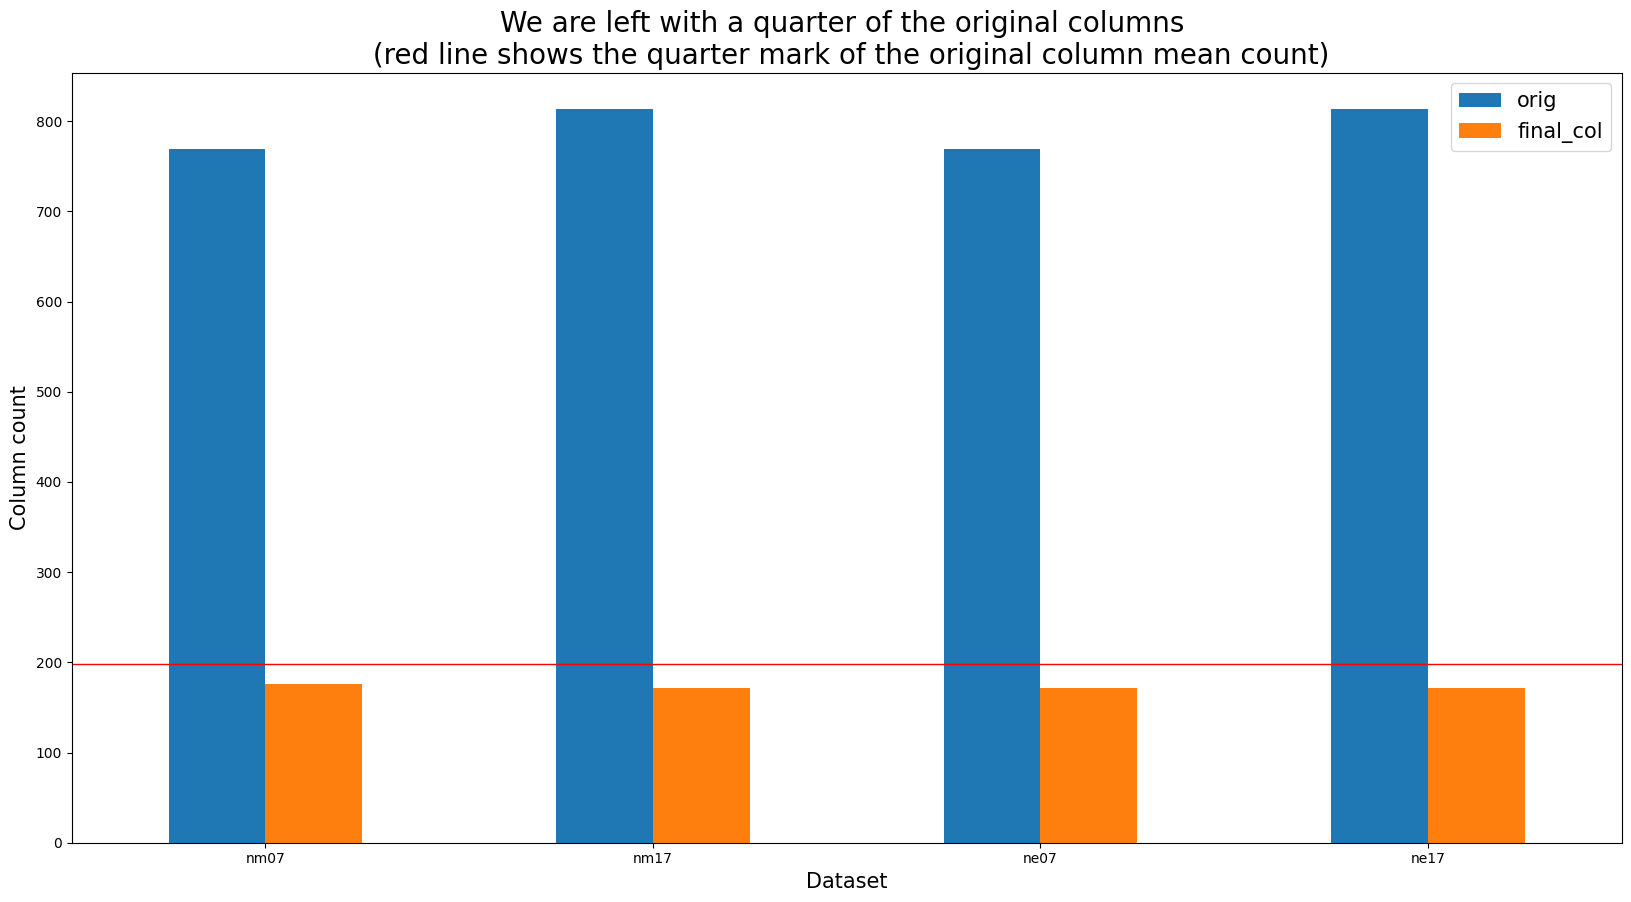

In [59]:
quarter = (all_df_att['orig'].mean())*.25

fig, ax = plt.subplots(figsize=(20,10))
all_df_att[['orig','final_col']].plot.bar(ax=ax)
plt.xlabel('Dataset',fontsize=15)
plt.ylabel('Column count',fontsize=15)
plt.xticks([0, 1, 2,3],labels=['nm07','nm17','ne07','ne17'],rotation=360)
plt.axhline(y=quarter,linewidth=1,color='r')
plt.legend(fontsize=15)
plt.title('We are left with a quarter of the original columns \n (red line shows the quarter mark of the original column mean count)',fontsize=20)
plt.savefig('../images/final_null.png');

### Save Clean Files

In [60]:
nm07_target.reset_index(drop=True,inplace=True)
nm07 = nm07.assign(CAT_ELIG=nm07_target)
nm07 = nm07.astype('float64')
nm07.to_csv('../data/clean_nm07.csv',index=None)

In [61]:
nm17_target.reset_index(drop=True,inplace=True)
nm17 = nm17.assign(CAT_ELIG=nm17_target)
nm17 = nm17.astype('float64')
nm17.to_csv('../data/clean_nm17.csv',index=None)

In [62]:
ne07_target.reset_index(drop=True,inplace=True)
ne07 = ne07.assign(CAT_ELIG=ne07_target)
ne07 = ne07.astype('float64')
ne07.to_csv('../data/clean_ne07.csv',index=None)

In [63]:
ne17_target.reset_index(drop=True,inplace=True)
ne17 = ne17.assign(CAT_ELIG=ne17_target)
ne17 = ne17.astype('float64')
ne17.to_csv('../data/clean_ne17.csv',index=None)